# 02 - Cleaning and de-duplication  (Req 1)

**Goal:** turn raw tweets into tidy, duplicate-free text, without losing the original.

The work is done by `src/02_clean.py` (about a minute); this notebook runs it and shows what changed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 110)
pd.set_option('display.width', 200)

%run ../src/02_clean.py

Raw rows loaded (train):                   1,600,000
Raw rows loaded (manual test):                  498
Removed missing / invalid-label rows:             0


Removed tweets empty after cleaning:          2,816


Removed repeated tweet_id:                    1,685


Removed same-user identical re-posts:        10,884


Kept but flagged (same text, other users):   80,082  -> column dup_group_size


Sampled emoticon-labelled tweets:           100,000  (random, seed 42)



Final rows after cleaning + dedup + sample: 100,493
Saved to C:\Users\Alvan\Desktop\NamPulse\data\interim\cleaned.csv
Label counts: {'positive': 50463, 'negative': 49891, 'neutral': 139}
Label source: {'emoticon': 100000, 'manual': 493}


## How many rows did each step remove?
Only *true* duplicates are removed: the same tweet twice, or the same user re-posting identical text.
Identical text from **different users** is kept and only flagged, because Req 4 (similarity index) needs to see repeated / coordinated messaging.

Finally the big file is **sampled to 100,000 tweets** (language detection on 1.6M would take hours; change `SAMPLE_SIZE` in the script to keep more). All hand-labelled tweets are kept.

In [2]:
print(open('../reports/cleaning_log.txt', encoding='utf-8').read())

Raw rows loaded (train):                   1,600,000
Raw rows loaded (manual test):                  498
Removed missing / invalid-label rows:             0
Removed tweets empty after cleaning:          2,816
Removed repeated tweet_id:                    1,685
Removed same-user identical re-posts:        10,884
Kept but flagged (same text, other users):   80,082  -> column dup_group_size
Sampled emoticon-labelled tweets:           100,000  (random, seed 42)

Final rows after cleaning + dedup + sample: 100,493
Saved to C:\Users\Alvan\Desktop\NamPulse\data\interim\cleaned.csv
Label counts: {'positive': 50463, 'negative': 49891, 'neutral': 139}
Label source: {'emoticon': 100000, 'manual': 493}


## Before vs after cleaning
`text_raw` is the original; `text_clean` has URLs, @mentions and HTML escapes removed (case and emojis are kept on purpose).

In [3]:
clean = pd.read_csv('../data/interim/cleaned.csv', parse_dates=['created_at'])
changed = clean[clean['text_raw'] != clean['text_clean']]
changed[['text_raw', 'text_clean']].sample(8, random_state=3)

,text_raw,text_clean
31013,i felt so sorry for that hollie on britains got talent last night glad she got through,i felt so sorry for that hollie on britains got talent last night glad she got through
10079,"@BJHewitt True, true, he told the major institutions of his day to go to hell.","True, true, he told the major institutions of his day to go to hell."
62222,"@TheKeenTaco Yeah Milk even surprised me. It was really good. KJI should be back up by tonight, so tacti...","Yeah Milk even surprised me. It was really good. KJI should be back up by tonight, so tactics says!"
43655,Finished the first twilight book,Finished the first twilight book
21329,@TWLOHA http://twitpic.com/5l8qo - BLUE!! More universal . . . altho my daughters would go for the pink...,- BLUE!! More universal . . . altho my daughters would go for the pink! lol Still voting for blue!
48190,"@Chazza_Moo ha! should have check my dates, thought Gemini was over before then Thx it was last week","ha! should have check my dates, thought Gemini was over before then Thx it was last week"
78693,Agh hot guy against hot guy This movie is messed up!,Agh hot guy against hot guy This movie is messed up!
66956,"@thisgoeshere haha ock drama I was hearing about it. its not used much, I just saw a comment about me and ...","haha ock drama I was hearing about it. its not used much, I just saw a comment about me and had to add hehe"


## Flagged (not deleted) duplicates
`dup_group_size` > 1 means other users posted the same text. Req 4 can group these.

In [4]:
flagged = clean[clean['dup_group_size'] > 1]
print(len(flagged), 'flagged rows in the sample')
flagged.sort_values('dup_group_size', ascending=False).drop_duplicates('text_clean')[['text_clean', 'dup_group_size', 'label']].head(10)

5106 flagged rows in the sample


,text_clean,dup_group_size,label
7924,Thanks!,1896,positive
6908,thanks!,1896,positive
74601,Thanks,1896,positive
13251,THANKS!!!!,1896,positive
13014,Thanks.,1896,positive
12747,thanks,1896,positive
82419,thanks!!,1896,positive
76429,thanks!!!!,1896,positive
11357,THANKS,1896,positive
78659,thanks.,1896,positive


## Sanity checks and label sources
`label_source`: **emoticon** labels are noisy guesses; **manual** labels were made by humans and are the trustworthy evaluation set (and the only place neutral exists).

{'rows': 100493, 'duplicate tweet_id': 0, 'empty text_clean': 0, 'missing labels': 0}
label         negative  neutral  positive
label_source                             
emoticon         49716        0     50284
manual             175      139       179


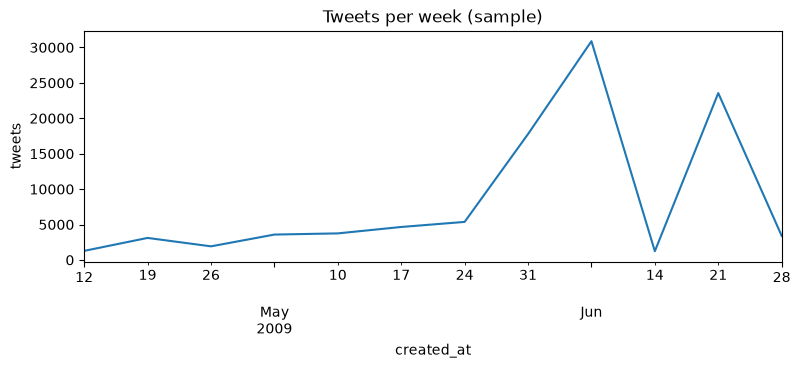

In [5]:
checks = {
    'rows': len(clean),
    'duplicate tweet_id': int(clean['tweet_id'].duplicated().sum()),
    'empty text_clean': int((clean['text_clean'].str.len() == 0).sum()),
    'missing labels': int(clean['label'].isna().sum()),
}
print(checks)
print(pd.crosstab(clean['label_source'], clean['label']))
clean.set_index('created_at').resample('W').size().plot(title='Tweets per week (sample)', figsize=(9, 3))
plt.ylabel('tweets'); plt.show()

## What we did and why
Cleaned text makes later models (TF-IDF, transformers) see words instead of noise, and removing true duplicates stops the same tweet being counted twice. The result is saved as an *interim* file; language detection is added in **notebook 03**.